AUC: 0.875
Accuracy: 0.8421052631578947

Confusion Matrix:
[[54 18]
 [ 0 42]]


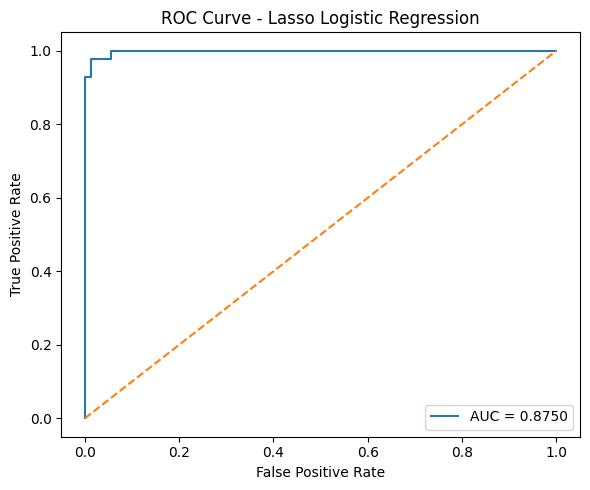

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve

#read data
file_path = r"C:\Users\Colin Briggs\Downloads\data.csv"
df = pd.read_csv(file_path)

#clean data
if "Unnamed: 32" in df.columns:
    df = df.drop(columns=["Unnamed: 32"])

if "id" in df.columns:
    df = df.drop(columns=["id"])

#encode target
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

#split X and y
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

#train test split (same as your model)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#lasso logistic regression
model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=500,
    C=0.05,
    random_state=42
)

model.fit(X_train_scaled, y_train)

#predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.2).astype(int)

#metrics
auc = roc_auc_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("AUC:", auc)
print("Accuracy:", acc)
print("\nConfusion Matrix:")
print(cm)

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Lasso Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()